# Sentinel-1 GRD Product: Radiometric Calibration

- **Goal:** Convert the raw SAR pixel values into physically meaningful radar backscatter (σ⁰, γ⁰, or β⁰).
- **Why:** removes effects caused by sensor settings, geometry, and acquisition mode; comparable across time, comparable between images.

### How
- Calibration factors found in quality/calibration 
- Follow [Radiometric Calibration Docs](https://sentinels.copernicus.eu/documents/247904/685163/S1-Radiometric-Calibration-V1.0.pdf) Section 4

In [1]:
import numpy as np
import xarray as xr
from xcube.core.store import new_data_store
from xcube_resampling import rectify_dataset, affine_transform_dataset
from xcube_resampling.gridmapping import GridMapping
from dask.distributed import Client, LocalCluster

xr.set_options(display_expand_attrs=False)

In [2]:
cluster = LocalCluster(
    n_workers=4,
    threads_per_worker=1,
    memory_limit="4GB",
    dashboard_address="8787",
)
client = Client(cluster)
client.dashboard_link

'http://127.0.0.1:8787/status'

2026-03-31 09:14:08,985 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:8787', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/home/konstantin/micromamba/envs/xcube-eopf/lib/python3.13/site-packages/tornado/websocket.py", line 938, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "/home/konstantin/micromamba/envs/xcube-eopf/lib/python3.13/site-packages/tornado/web.py", line 3301, in wrapper
    return method(self, *args, **kwargs)
  File "/home/konstantin/micromamba/envs/xcube-eopf/lib/python3.13/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired. Configure the app with a larger value for --ses

In [3]:
path = (
    "data/S1C_IW_GRDH_1SDV_20260331T043117_20260331T043142_007003_00E2E3_7002.zarr"
)

In [4]:
%%time
dt = xr.open_datatree(path, engine="zarr", chunks={})
dt

CPU times: user 104 ms, sys: 3.07 ms, total: 107 ms
Wall time: 105 ms


<xarray.DataTree>
Group: /
│   Attributes: (2)
├── Group: /S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH
│   │   Attributes: (3)
│   ├── Group: /S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions
│   │   ├── Group: /S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/antenna_pattern
│   │   │       Dimensions:              (azimuth_time: 28, count: 693)
│   │   │       Coordinates:
│   │   │         * azimuth_time         (azimuth_time) datetime64[ns] 224B 2026-03-31T04:31:...
│   │   │         * count                (count) int64 6kB 0 1 2 3 4 5 ... 688 689 690 691 692
│   │   │       Data variables:
│   │   │           elevation_angle      (azimuth_time, count) float32 78kB dask.array<chunksize=(28, 693), meta=np.ndarray>
│   │   │           incidence_angle      (azimuth_time, count) float32 78kB dask.array<chunksize=(28, 693), meta=np.ndarray>
│   │   │           roll                 (azimuth_time) float64 224B dask.array<chunksize=(28,), meta=np.ndarray>
│   │   │           slant_range_time_ap  (azimuth_time, count) float64 155kB dask.array<chunksize=(28, 693), meta=np.ndarray>
│   │   │           swath                (azimuth_time) <U3 336B dask.array<chunksize=(28,), meta=np.ndarray>
│   │   │           terrain_height       (azimuth_time) float64 224B dask.array<chunksize=(28,), meta=np.ndarray>
│   │   ├── Group: /S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/attitude
│   │   │       Dimensions:       (azimuth_time: 25)
│   │   │       Coordinates:
│   │   │         * azimuth_time  (azimuth_time) datetime64[ns] 200B 2026-03-31T04:31:17.9999...
│   │   │       Data variables:
│   │   │           pitch         (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           q0            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           q1            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           q2            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           q3            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           roll          (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           wx            (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           wy            (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           wz            (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           yaw           (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   ├── Group: /S01SIWGRD_20260331T043117_0025_C040_7002_00E2E3_VH/conditions/doppler_centroid
│   │   │       Dimensions:                            (azimuth_time: 27, degree: 3)
│   │   │       Coordinates:
│   │   │         * azimuth_time                       (azimuth_time) datetime64[ns] 216B 202...
│   │   │         * degree                             (degree) int64 24B 2 1 0
│   │   │       Data variables:
│   │   │           data_dc_polynomial                 (azimuth_time, degree) float32 324B dask.array<chunksize=(27, 3), meta=np.ndarray>
│   │   │           data_dc_rms_error                  (azimuth_time) float64 216B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           data_dc_rms_error_above_threshold  (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           fine_dce_azimuth_start_time        (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           fine_dce_azimuth_stop_time         (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           geometry_dc_polynomial             (azimuth_time, degree) float32 324B dask.array<chunksize=(27, 3), meta=np.ndarray>
│   │   │           t0                                 (azimuth_time) float64 216

In [5]:
%%time
group_VH = [x for x in dt.children if "VH" in x][0]
grd = dt[group_VH].measurements.to_dataset().rename({"grd": "vh"})
group_VV = [x for x in dt.children if "VV" in x][0]
grd["vv"] = dt[group_VV].measurements.to_dataset().grd
grd

CPU times: user 2.56 ms, sys: 43 μs, total: 2.6 ms
Wall time: 2.02 ms


<xarray.Dataset> Size: 2GB
Dimensions:       (azimuth_time: 16700, ground_range: 26001)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 134kB 2026-03-31T04:31:17.565...
    line          (azimuth_time) int64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range  (ground_range) float64 208kB 0.0 10.0 20.0 ... 2.6e+05 2.6e+05
    pixel         (ground_range) int64 208kB dask.array<chunksize=(2048,), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) uint16 868MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    vv            (azimuth_time, ground_range) uint16 868MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

In [6]:
%%time
grd = grd.assign_coords(azimuth_time=(grd.azimuth_time - grd.azimuth_time[0]) / np.timedelta64(1, "s"))
grd

CPU times: user 70.9 ms, sys: 15.2 ms, total: 86.2 ms
Wall time: 1.09 s


<xarray.Dataset> Size: 2GB
Dimensions:       (azimuth_time: 16700, ground_range: 26001)
Coordinates:
  * azimuth_time  (azimuth_time) float64 134kB 0.0 0.001497 ... 25.0 25.0
    line          (azimuth_time) int64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range  (ground_range) float64 208kB 0.0 10.0 20.0 ... 2.6e+05 2.6e+05
    pixel         (ground_range) int64 208kB dask.array<chunksize=(2048,), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) uint16 868MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    vv            (azimuth_time, ground_range) uint16 868MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

In [7]:
%%time
gm = GridMapping.from_coords(
    grd.ground_range,
    grd.azimuth_time,
    "EPSG:4326",
    tile_size=(grd.vv.data.chunksize[1], grd.vv.data.chunksize[0]),
)
gm

CPU times: user 74.4 ms, sys: 10.3 ms, total: 84.6 ms
Wall time: 210 ms


class: **Coords1DGridMapping**
* is_regular: True
* is_j_axis_up: True
* is_lon_360: True
* crs: EPSG:4326
* xy_res: (10, 0.001497)
* xy_bbox: (-5, -0.0007485, 260005, 25)
* ij_bbox: (0, 0, 26001, 16700)
* xy_dim_names: ('ground_range', 'azimuth_time')
* xy_var_names: ('ground_range', 'azimuth_time')
* size: (26001, 16700)
* tile_size: (2048, 2048)

> Note!  
> Different calibration are possible; maybe also use also `beta_nought`, `gamma`, and `dn`.

In [8]:
%%time
sigma_lut = dt[group_VH].quality.calibration.to_dataset()[["sigma_nought"]]
sigma_lut = sigma_lut.assign_coords(azimuth_time=(sigma_lut.azimuth_time - sigma_lut.azimuth_time[0]) / np.timedelta64(1, "s"))
sigma_lut = sigma_lut.isel(ground_range=slice(0, -1))
sigma_lut

CPU times: user 31.5 ms, sys: 3.88 ms, total: 35.4 ms
Wall time: 55.1 ms


<xarray.Dataset> Size: 78kB
Dimensions:       (azimuth_time: 27, ground_range: 650)
Coordinates:
  * azimuth_time  (azimuth_time) float64 216B 0.0 1.0 2.0 3.0 ... 24.0 25.0 26.0
    line          (azimuth_time) int32 108B dask.array<chunksize=(27,), meta=np.ndarray>
  * ground_range  (ground_range) float64 5kB 0.0 400.0 ... 2.592e+05 2.596e+05
    pixel         (ground_range) int32 3kB dask.array<chunksize=(650,), meta=np.ndarray>
Data variables:
    sigma_nought  (azimuth_time, ground_range) float32 70kB dask.array<chunksize=(27, 650), meta=np.ndarray>

In [9]:
%%time
source_gm = GridMapping.from_coords(sigma_lut.ground_range, sigma_lut.azimuth_time, "EPSG:4326")
source_gm

CPU times: user 61.4 ms, sys: 6.95 ms, total: 68.3 ms
Wall time: 173 ms


class: **Coords1DGridMapping**
* is_regular: True
* is_j_axis_up: True
* is_lon_360: True
* crs: EPSG:4326
* xy_res: (400, 1)
* xy_bbox: (-200, -0.5, 259800, 26.5)
* ij_bbox: (0, 0, 650, 27)
* xy_dim_names: ('ground_range', 'azimuth_time')
* xy_var_names: ('ground_range', 'azimuth_time')
* size: (650, 27)
* tile_size: (650, 27)

In [10]:
%%time
sigma_lut_interp = affine_transform_dataset(
    sigma_lut,
    target_gm=gm,
    source_gm=source_gm,
)
sigma_lut_interp

CPU times: user 27.8 ms, sys: 2.15 ms, total: 29.9 ms
Wall time: 27.8 ms


<xarray.Dataset> Size: 2GB
Dimensions:       (azimuth_time: 16700, ground_range: 26001)
Coordinates:
  * azimuth_time  (azimuth_time) float64 134kB 0.0 0.001497 ... 25.0 25.0
    line          (azimuth_time) int64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range  (ground_range) float64 208kB 0.0 10.0 20.0 ... 2.6e+05 2.6e+05
    pixel         (ground_range) int64 208kB dask.array<chunksize=(2048,), meta=np.ndarray>
    spatial_ref   int64 8B 0
Data variables:
    sigma_nought  (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

In [11]:
%%time
sigma_0 = (grd**2) / (sigma_lut_interp.sigma_nought**2)
sigma_0

CPU times: user 4.13 ms, sys: 929 μs, total: 5.05 ms
Wall time: 4.53 ms


<xarray.Dataset> Size: 3GB
Dimensions:       (ground_range: 26001, azimuth_time: 16700)
Coordinates:
  * ground_range  (ground_range) float64 208kB 0.0 10.0 20.0 ... 2.6e+05 2.6e+05
    pixel         (ground_range) int64 208kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * azimuth_time  (azimuth_time) float64 134kB 0.0 0.001497 ... 25.0 25.0
    line          (azimuth_time) int64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
    spatial_ref   int64 8B 0
Data variables:
    vh            (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    vv            (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes: (4)

In [12]:
%%time
store = new_data_store("file", root="data")

CPU times: user 22.5 ms, sys: 11 ms, total: 33.5 ms
Wall time: 43.5 ms


In [13]:
%%time
store.write_data(sigma_0, "sen1_radio_calib.zarr", replace=True)

CPU times: user 3.02 s, sys: 288 ms, total: 3.31 s
Wall time: 11.1 s


'sen1_radio_calib.zarr'

In [14]:
%%time
ds = store.open_data("sen1_radio_calib.zarr")
ds

CPU times: user 15 ms, sys: 914 μs, total: 15.9 ms
Wall time: 14.6 ms


<xarray.Dataset> Size: 3GB
Dimensions:       (azimuth_time: 16700, ground_range: 26001)
Coordinates:
  * azimuth_time  (azimuth_time) float64 134kB 0.0 0.001497 ... 25.0 25.0
    line          (azimuth_time) int64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range  (ground_range) float64 208kB 0.0 10.0 20.0 ... 2.6e+05 2.6e+05
    pixel         (ground_range) int64 208kB dask.array<chunksize=(2048,), meta=np.ndarray>
    spatial_ref   int64 8B ...
Data variables:
    vh            (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    vv            (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes: (4)

CPU times: user 812 ms, sys: 103 ms, total: 915 ms
Wall time: 1.68 s


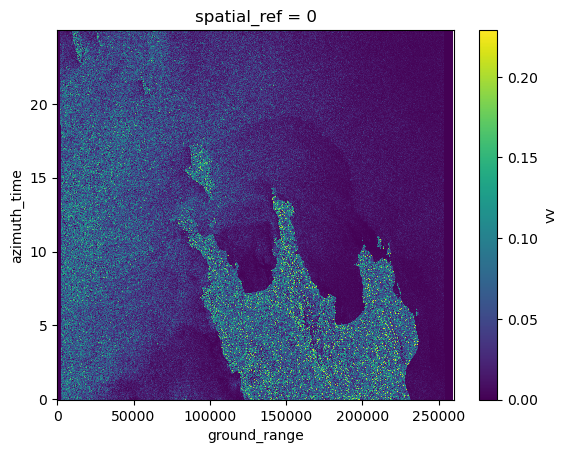

In [15]:
%%time
ds.vv[::20, ::20].plot()